# Case: California Housing – modellering som beslutsunderlag

**Student:** Wendy Mermet  
**Datakälla:** `data/housing.csv`


In [1]:
import src.TrainingTools as tt
import src.io_utils as io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Lada Data och EDA

### Strategisammanfattning för EDA

<u>1. Kvalitetskontroll av data</u>
- Vi börjar med att granska datasetets kvalitet genom att kontrollera:
  - Saknade värden i kolumner
  - Eventuella dubbletter
  - Datatyper för varje kolumn
- Detta steg säkerställer att vi arbetar med ett korrekt och pålitligt underlag.

<u>2. Skapande av målvariabel</u>
- Vi skapar en ny kolumn som indikerar om **`median_house_value`** ingår i de **översta 20 %** av värdena eller inte.
- Detta görs för att kunna formulera problemet som en klassificeringsuppgift.

<u>3. Skalning av numeriska funktioner</u>
- Vi lägger till två nya kolumner som kan förbättra modellens prestanda ("rooms per household" & "bedrooms per households")
- Eftersom våra numeriska kolumner har stora skillnader i storlek och enheter, är det nödvändigt att **skala dem**.
- Syftet är att undvika att vissa funktioner dominerar maskininlärningsmodellen på grund av sina större värden.


<u>4. Hantering av kategoriska funktioner</u>
- Den kategoriska kolumnen `ocean_proximity` behöver **one-hot-encoding** för att kunna användas i modeller som kräver numeriska värden.
- Detta steg omvandlar kategorierna till binära kolumner.

<u>5. Relevansanalys</u>
- Vi utvärderar varje funktion i relation till målvariabeln med hjälp av en korrelationsmatris.
- Detta steg hjälper oss att identifiera vilka funktioner som är mest relevanta för prediktionen av målvariabeln.

In [2]:
from src.io_utils import df
df_info = io.check_data(df)

print("\n===========================================================================\n")

df_stats = io.stats_data(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


Number of rows and columns: (20640, 10)

Missing values per column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households         

In [3]:
# Show the actual duplicate rows
duplicate_rows = df[df.duplicated()]
print("Duplicate rows:\n", duplicate_rows)

Duplicate rows:
 Empty DataFrame
Columns: [longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value, ocean_proximity]
Index: []


In [4]:
# adding extra columns for more detailed analysis
data_prep = tt.TrainingTools()
df_reworked = df.copy()
df_reworked = data_prep.prepare_data(df_reworked)

print("Target distribution:")
print(df_reworked["target"].value_counts())



Target distribution:
target
0    16510
1     4130
Name: count, dtype: int64


In [5]:
# EDA - using Transformer and scaller for easier analysis and visualization
numeric_features_EDA = ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income","median_house_value", "rooms_per_household", "bedrooms_per_household"]
categorical_features_EDA = ["ocean_proximity"]



preprocess_EDA = data_prep.preprocess_data(numeric_features_EDA, categorical_features_EDA)
preprocess_EDA.set_output(transform="pandas")
df_EDA = df.copy()
df_EDA["rooms_per_household"] = df_EDA["total_rooms"] / df_EDA["households"]
df_EDA["bedrooms_per_household"] = df_EDA["total_bedrooms"] / df_EDA["households"]

df_EDA_trans = preprocess_EDA.fit_transform(df_EDA)
df_EDA_trans.head()
print("EDA - Transformed DataFrame Shape:", df_EDA_trans.shape)



EDA - Transformed DataFrame Shape: (20640, 16)


In [6]:

def save_plot(fig, filename, dpi=150, tight=True):
    """
    Save a matplotlib/seaborn figure so that it matches the notebook display.
    
    Parameters:
    - fig: matplotlib.figure.Figure object
    - filename: str, path to save the file (e.g., "EDA_corr_mat_full.png")
    - dpi: int, resolution of the saved image
    - tight: bool, whether to apply tight_layout
    """
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches='tight')  # ensure no labels are cut
    print(f"Saved figure to {filename}")


Saved figure to EDA_corr_mat_full.png


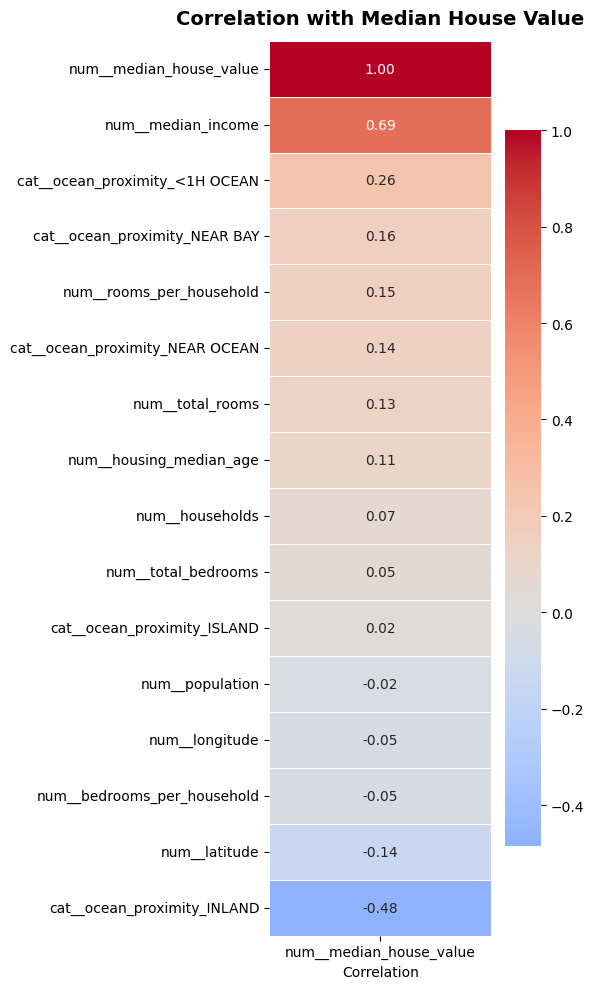

In [7]:
# Correlation matrix and heatmap of all features with the target variable
df_corr_EDA_full = df_EDA_trans.copy()

corr_matrix_full = df_corr_EDA_full.corr()

# Sort values
corr_target = corr_matrix_full[["num__median_house_value"]] \
    .sort_values(by="num__median_house_value", ascending=False)

fig = plt.figure(figsize=(6, 10))

ax = sns.heatmap(
    corr_target,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,              # important for correlations
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10}
)

# Title styling
plt.title(
    "Correlation with Median House Value",
    fontsize=14,
    fontweight="bold",
    pad=12
)

# Clean axis labels
ax.set_ylabel("")
ax.set_xlabel("Correlation")


plt.tight_layout()
save_plot(fig, "EDA_corr_mat_full.png")
plt.show()


Saved figure to EDA_corr_mat_main.png


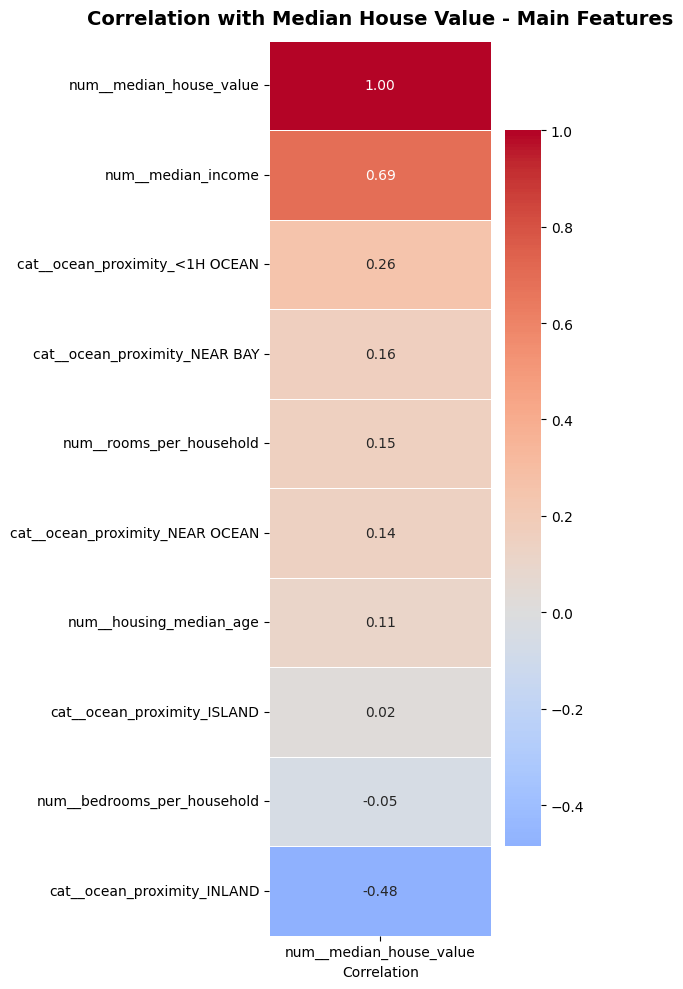

In [8]:
# Based on the correlation matrix, we can see that some features have a stronger correlation with the target variable (median house value) than others. 
# For example, "num__median_income" has a strong positive correlation, while "num__longitude" and "num__latitude" have very low correlations. 
# Additionally, some features like "num__total_rooms" and "num__households" are highly correlated with each other, which can lead to multicollinearity issues in modeling. 
# Therefore, we will focus on the features that have a stronger correlation with the target variable and remove those that have low correlation or are highly correlated with each other for our main analysis.

df_corr_EDA_main = df_corr_EDA_full.drop(columns=["num__longitude", "num__latitude","num__population","num__total_bedrooms","num__total_rooms", "num__households"])# delete features with low correlation to target and high correlation to each other

corr_matrix_main = df_corr_EDA_main.corr()


# Sort values
corr_target_main = corr_matrix_main[["num__median_house_value"]] \
    .sort_values(by="num__median_house_value", ascending=False)

fig =plt.figure(figsize=(6, 10))

ax = sns.heatmap(
    corr_target_main,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,              # important for correlations
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10}
)

# Title styling
plt.title(
    "Correlation with Median House Value - Main Features",
    fontsize=14,
    fontweight="bold",
    pad=12
)

# Clean axis labels
ax.set_ylabel("")
ax.set_xlabel("Correlation")


plt.tight_layout()
save_plot(plt.gcf(), "EDA_corr_mat_main.png")
plt.show()

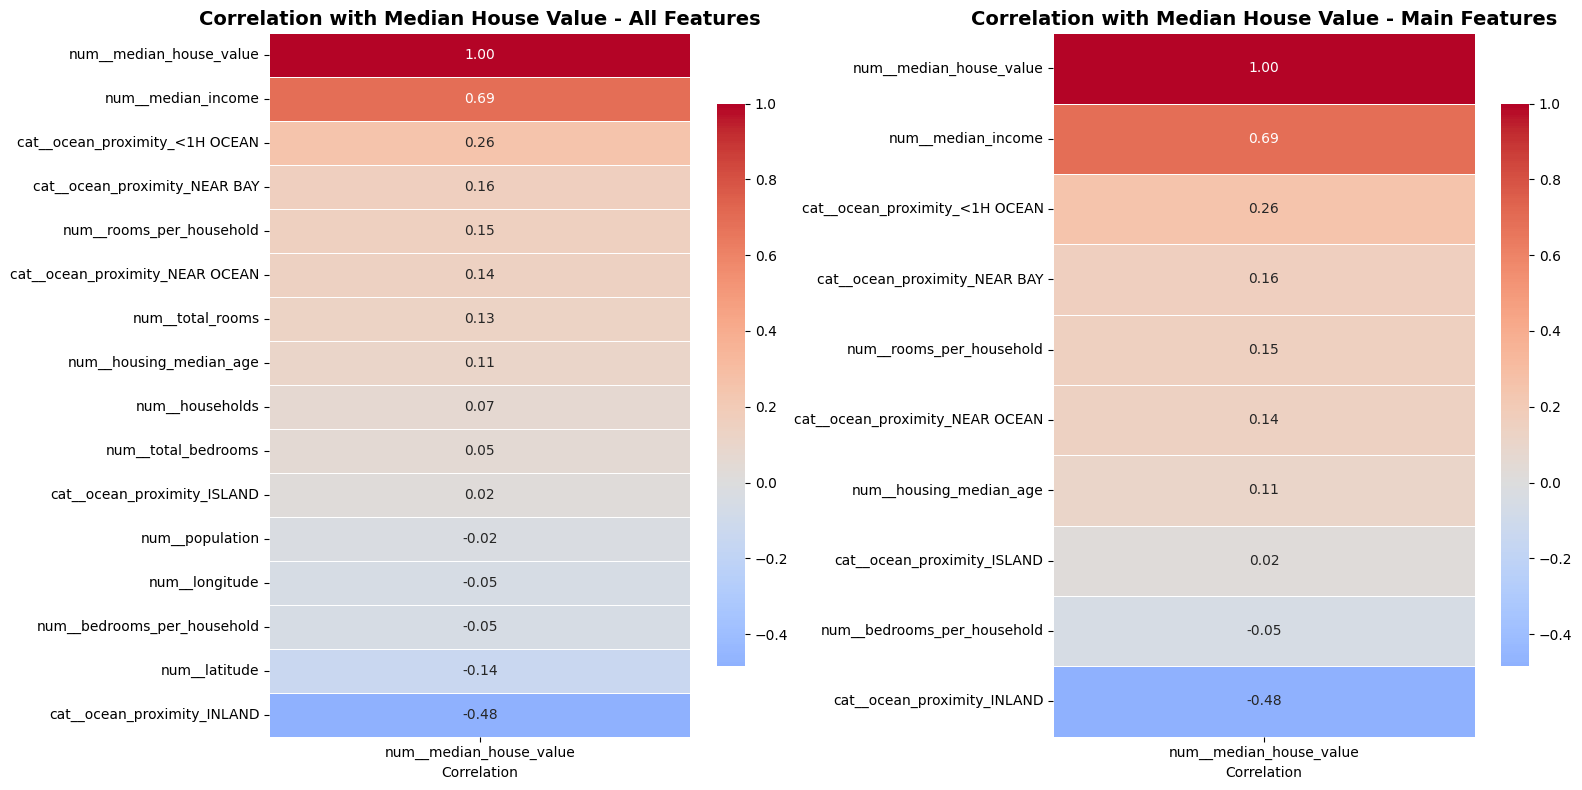

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2 rows, 1 column
fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # side by side

# --- Plot 1: Full features correlation ---
sns.heatmap(
    corr_target,  # full features correlation matrix
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10},
    ax=axes[0]
)
axes[0].set_title("Correlation with Median House Value - All Features", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Correlation")
axes[0].set_ylabel("")

# --- Plot 2: Main features correlation ---
sns.heatmap(
    corr_target_main,  # correlation matrix for main features
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10},
    ax=axes[1]
)
axes[1].set_title("Correlation with Median House Value - Main Features", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Correlation")
axes[1].set_ylabel("")

# Adjust layout to avoid overlap
plt.tight_layout()

# Save entire dashboard
fig.savefig("EDA_correlation_dashboard.png", dpi=150)

# Show dashboard
plt.show()

## Resultatsammanfattning av initial EDA

- **Saknade värden:**  
  - Numeriska variabler har fyllts i med medianen för respektive kolumn.  
  - Kategoriska variabler har fyllts i med det mest frekventa värdet.  
  Detta säkerställer att datasetet inte innehåller några saknade värden och är redo för vidare analys.

- **Obalanserad target:**  
  - Vårt mål (`target`) är obalanserat med fördelningen 20% positivt och 80% negativt.  
  - Detta påverkar valet av utvärderingsmetrik, där fokus bör ligga på att minimera falska negativa (t.ex. med recall).

- **Feature-selektion:**  
  - Av de ursprungliga 11 variablerna har vi valt ut 5 som är mest relevanta för vårt mål:  
    1. `ocean_proximity`  
    2. `median_income`  
    3. `rooms_per_household`  
    4. `housing_median_age`  
    5. `bedrooms_per_household`  
  - Syftet med att ta bort irrelevanta features är att bygga en enkel och stabil modell, vilket både förbättrar prestanda och gör modellen lättare att tolka.

- Denna initiala datarensning och selektion av features ger ett mer fokuserat och kvalitativt dataset, vilket underlättar modellering och tolkning.


## Syfte med PCA

- **Dimensionalitetsreduktion:**  
  PCA (Principal Component Analysis) används för att minska antalet variabler i datasetet utan att förlora för mycket information.  
  Detta gör analysen och modellerna enklare och snabbare att träna.

- **Identifiera mönster och relationer:**  
  Genom att transformera data till nya huvudkomponenter kan vi upptäcka underliggande strukturer, mönster eller korrelationer mellan variabler.

- **Förbättra modellprestanda:**  
  Genom att reducera brus och redundanta variabler kan PCA bidra till mer stabila och generaliserbara modeller.

- **Visualisering:**  
  PCA gör det möjligt att visualisera höga dimensioner i två eller tre komponenter, vilket underlättar tolkning och presentation av data.

In [10]:
# PCA - copying the original dataframe to keep it clean for later use and adding the extra columns for PCA analysis as well
df_PCA = df.copy()

df_PCA = data_prep.prepare_data(df_PCA)

df_PCA.head()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_household,target
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,1.023810,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.971880,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,1.073446,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,1.073059,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,1.081081,1


In [11]:
# For PCA analysis, we need to slpit the dataframe into features and target variable, and also check for missing values before applying PCA
# We will base our analysis only on the feautres (no target variable, and also no median house value since it is the same as the target variable but not scaled)
X_pca_full = df_PCA.drop(columns=["target", "median_house_value"])
y_true_pca = df_PCA["target"]

print("X Shape:", X_pca_full.shape)
print("y_true Shape:", y_true_pca.shape)

# Check for missing values
print("Missing values per column (features):\n", X_pca_full.isna().sum())
print("Missing values per column (target):\n", y_true_pca.isna().sum())


X Shape: (20640, 11)
y_true Shape: (20640,)
Missing values per column (features):
 longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms            207
population                  0
households                  0
median_income               0
ocean_proximity             0
rooms_per_household         0
bedrooms_per_household    207
dtype: int64
Missing values per column (target):
 0


In [12]:
#PCA - using transformer and scaller for easier analysis and visualization, and also to be able to use the same preprocessor for modeling later on
numeric_features_PCA= ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income", "rooms_per_household", "bedrooms_per_household"]
categorical_features_PCA = ["ocean_proximity"]

preprocess_PCA = data_prep.preprocess_data(numeric_features_PCA, categorical_features_PCA)
preprocess_PCA.set_output(transform="pandas")


X_PCA_trans = preprocess_PCA.fit_transform(X_pca_full)
X_PCA_trans.head()

X_PCA_ready = X_PCA_trans.drop(columns=["num__longitude", "num__latitude","num__population","num__total_bedrooms","num__total_rooms", "num__households"])# delete features with low correlation to target and high correlation to each other


In [13]:
#Applying PCA and checking explained variance ratio to determine how many components to keep for modeling

from src.TrainingTools import PCA
pca = PCA()

X_PCA_ready = pca.fit_transform(X_PCA_ready)
explained_ratio = pca.explained_variance_ratio_
cum_explained_ratio = np.cumsum(explained_ratio)

print("explained variance ratio (alla):", np.round(explained_ratio[:10], 4))
print("Cumulative explained variance (alla):", np.round(cum_explained_ratio[:10], 4))


explained variance ratio (alla): [4.136e-01 2.377e-01 2.034e-01 7.220e-02 3.660e-02 2.390e-02 1.250e-02
 1.000e-04 0.000e+00]
Cumulative explained variance (alla): [0.4136 0.6514 0.8547 0.927  0.9636 0.9875 0.9999 1.     1.    ]


Saved figure to PCA_explained_variance.png


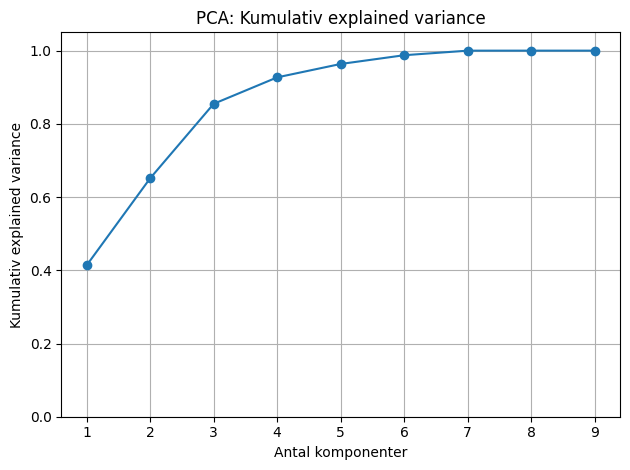

In [14]:
# Based on the explained variance ratio, we can see that the first few principal components capture a significant portion of the variance in the data.

fig = plt.figure()
plt.plot(range(1, len(cum_explained_ratio) + 1), cum_explained_ratio, marker="o")
plt.xlabel("Antal komponenter")
plt.ylabel("Kumulativ explained variance")
plt.title("PCA: Kumulativ explained variance")
plt.ylim(0, 1.05)
plt.grid(True)

plt.tight_layout()
save_plot(fig, "PCA_explained_variance.png")
plt.show()

In [15]:
# Determine the number of components needed to explain at least 90% of the variance. Additionally we are checking the impact of the first two main PCA component

n_90 = int(np.argmax(cum_explained_ratio >= 0.90) + 1)
print("Min components for >= 90% explained variance", n_90)

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_PCA_ready)

pca_90 = PCA(n_components=n_90)
X_pca_90 = pca_90.fit_transform(X_PCA_ready)

print("Explained variance (PC1, PC2):", np.round(pca_2.explained_variance_ratio_, 4))
print("Total explained variance (2 components):", np.round(float(pca_2.explained_variance_ratio_.sum()),4))


print("Explained variance (PC1, PC2, ..., PC8):", np.round(pca_90.explained_variance_ratio_, 4))
print("Total explained variance (8 components):", np.round(float(pca_90.explained_variance_ratio_.sum()),4))

Min components for >= 90% explained variance 4
Explained variance (PC1, PC2): [0.4136 0.2377]
Total explained variance (2 components): 0.6514
Explained variance (PC1, PC2, ..., PC8): [0.4136 0.2377 0.2034 0.0722]
Total explained variance (8 components): 0.927


Saved figure to PCA_loadings.png


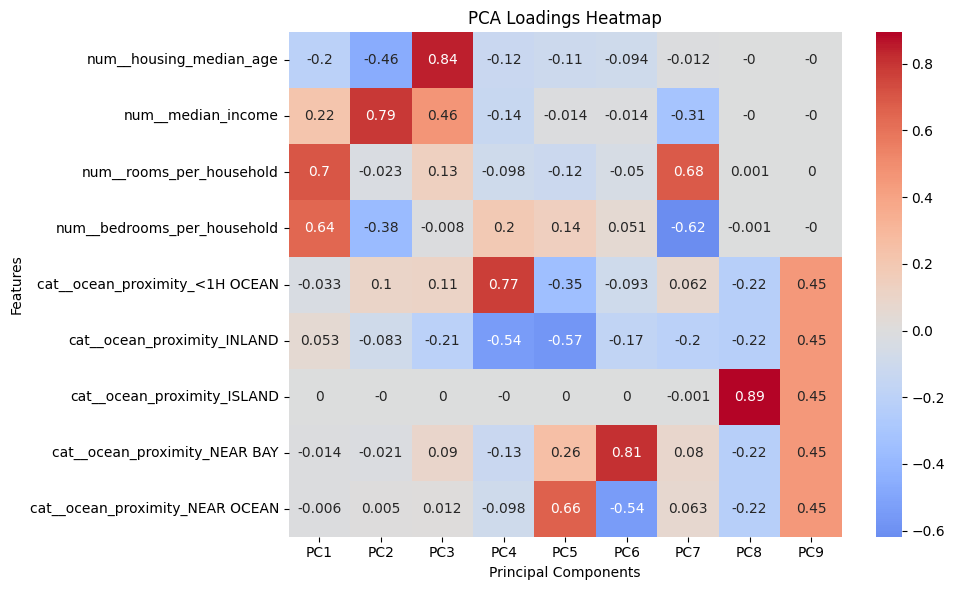

In [16]:
# PCA loadings heatmap to visualize the contribution of each original feature to the principal components

feature_names = ["num__housing_median_age", "num__median_income", "num__rooms_per_household", "num__bedrooms_per_household", "cat__ocean_proximity_<1H OCEAN", "cat__ocean_proximity_INLAND", "cat__ocean_proximity_ISLAND", "cat__ocean_proximity_NEAR BAY", "cat__ocean_proximity_NEAR OCEAN"]  # add all columns used in PCA

X_df = pd.DataFrame(X_PCA_ready, columns=feature_names)

# Create PCA loadings DataFrame
loadings = pd.DataFrame(pca.components_.T, index=X_df.columns, columns=[f'PC{i+1}' for i in range(len(pca.components_))])
loadings_rounded = loadings.round(3)

fig = plt.figure(figsize=(10, 6))
sns.heatmap(loadings_rounded, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings Heatmap")
plt.ylabel("Features")
plt.xlabel("Principal Components")
plt.tight_layout()


save_plot(fig, "PCA_loadings.png")
plt.show()

## Resultat av PCA

- **Förklarad varians per komponent:**  
  Den första huvudkomponenten (PC1) förklarar cirka 41,4% av variationen i data.  
  Den andra komponenten (PC2) förklarar ytterligare 23,8%, och tillsammans med PC1 står de för totalt 65,1% av variationen.  
  De fyra första komponenterna (PC1–PC4) förklarar totalt 92,7% av variationen, vilket innebär att majoriteten av informationen i datasetet fångas av dessa fyra komponenter.

  För att fånga minst 90% av datasetets totala variation krävs **minst 4 komponenter**.  
  Detta innebär att vi kan reducera våra ursprungliga 9 numeriska variabler till 4 huvudkomponenter utan att förlora mycket information.  

- **Tolkning av PC komponenter:**
  - PC1: Domineras av `num__rooms_per_household` och `num__bedrooms_per_household`, vilket tyder på att denna komponent fångar boendestandard/utrymme per hushåll.  
  - PC2: Starkt bidrag från `num__median_income` och `num__housing_median_age`, vilket tyder på socioekonomiska faktorer och byggnadens ålder.  
  - PC3: Domineras av `num__housing_median_age`, visar variation i åldern på bostäder.  
  - PC4: Starkt bidrag från kategoriska `ocean_proximity`-features, vilket indikerar geografisk placering nära havet.  
  - PC5–PC9: Mindre viktiga komponenter, men fångar blandade effekter från kategoriska funktioner och detaljerade variationer i numeriska features.

Med denna analys kan vi förstå **vilka ursprungliga features som påverkar varje huvudkomponent mest**, och använda de första komponenterna för att reducera dimensionaliteten utan större informationsförlust.

## Strategi för maskininlärning

- **Datapreparation:**  
  Vi går tillbaka till huvuddataframen och förbereder datan genom att:
  - Lägga till extra kolumner (t.ex. `rooms_per_household` och `bedrooms_per_household`)  
  - Skapa målvariabeln (target) som indikerar om median-husvärdet ligger i topp 20%

- **Datadelningsstrategi:**  
  - Vi delar upp datasetet i features (X) och target (y)  
  - Därefter delas datan upp i tränings- och testdata **från början** för att undvika dataläckage  
  - Vi använder `stratify=y` eftersom målvariabeln är obalanserad (20%/80%)

- **Dataförbehandling:**  
  - Vi använder våra transformatorer och skalare för numeriska och kategoriska features  
  - Vi tar bort irrelevanta features för att minska brus och hålla modellen enkel    

- **Modellträning:**  
  - Vi tränar tre modeller via pipelines som säkerställer att PCA körs först innan modellen tränas:      
      - Logistic Regression (Baseline)  
      - Decision Tree  
      - Random Forest  
  - Vi använder 5-faldig korsvalidering (CV) med `scoring="recall"` för att minimera falska negativa, eftersom vi inte vill missa områden med högt husvärde  

- **Modellurval och testning:**  
  - De två bästa modellerna väljs ut för vidare parameteroptimering med `GridSearchCV`  
  - Den bästa modellen med de optimala parametrarna väljs som slutmodell  
  - Slutmodellen appliceras därefter på testdatan för en opartisk utvärdering  
  - Innan prediktion på testdata appliceras samma **transformeringar, skalning och feature-selektion** som användes under träning, för att säkerställa konsistens och undvika dataläckage

In [17]:
# ML - preparing the data for modeling. We are also creating a binary target variable based on the top 20% of median house values.

n = 20 # top 20% as target
df_ml = data_prep.prepare_data(df, n)

target_dict = {0: f"Not Top {n}%", 1: f"Top {n}%"}
target_names = [target_dict[i] for i in sorted(target_dict)]

#display(df_ml.head())



In [18]:
# Splitting the data into training and test sets, with stratification to maintain the same class distribution in both sets. 
# No transformation is applied at this stage to avoid data leakage.
# We are also checking the class distribution in the train and test sets to ensure that they are similar.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict


X = df_ml.drop(columns=["target","median_house_value"])
y = df_ml["target"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=42,
    stratify=y
)


print("Train:", X_train.shape)
print("Test :", X_test.shape)


print("\nKlassfördelning train:")
print(y_train.value_counts(normalize=True))

print("\nKlassfördelning test:")
print(y_test.value_counts(normalize=True))



Train: (14448, 11)
Test : (6192, 11)

Klassfördelning train:
target
0    0.799903
1    0.200097
Name: proportion, dtype: float64

Klassfördelning test:
target
0    0.799903
1    0.200097
Name: proportion, dtype: float64


In [19]:
# Applying Transformer and scaller for easier analysis and visualization, and droping the features with low correlation to target and high correlation to each other for modeling
import src.TrainingTools as tt
from sklearn.pipeline import Pipeline

numeric_features_ML= ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income", "rooms_per_household", "bedrooms_per_household"]
categorical_features_ML = ["ocean_proximity"]

preprocess_ML = data_prep.preprocess_data(numeric_features_ML, categorical_features_ML)
preprocess_ML.set_output(transform="pandas")

X_train_trans = preprocess_ML.fit_transform(X_train)


X_train_ready = X_train_trans.drop(columns=["num__longitude", "num__latitude","num__population","num__total_bedrooms","num__total_rooms", "num__households"])# delete features with low correlation to target and high correlation to each other
print(f"Shape of X_train: {X_train_ready.shape}")

Shape of X_train: (14448, 9)


In [20]:
# pipelines for modeling with PCA and different classifiers. 
# CV prepared for GridSearchCV and cross-validation, with recall as the scoring metric to focus on correctly identifying the top 20% of median house values.

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression(
        max_iter=5000,
        random_state=42)

tree =  DecisionTreeClassifier(
        random_state=42)

    
rf = RandomForestClassifier(
        n_estimators=300, 
        random_state=42,
        n_jobs=-1)

pca_ML = PCA(8)

pipe_lr = Pipeline([("PCA", pca_ML), ("model", logreg)])
pipe_rf = Pipeline([("PCA", pca_ML), ("model", rf)])
pipe_tree = Pipeline([("PCA", pca_ML), ("model", tree)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "recall"


In [21]:
# Modeling on training data - evaluating the baseline performance of the three classifiers using cross-validation with recall as the scoring metric. 

baseline_rows = []

for name, pipe in [("LogisticRegression", pipe_lr), ("RandomForest", pipe_rf), ("DecisionTree", pipe_tree)]:
    scores = cross_val_score(pipe, X_train_ready, y_train, cv=cv, scoring=SCORING)
    baseline_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

baseline_table = pd.DataFrame(baseline_rows).sort_values("mean", ascending=False)
baseline_table

,model,mean,std
2,DecisionTree,0.584921,0.019463
1,RandomForest,0.576964,0.015069
0,LogisticRegression,0.535113,0.018114


In [22]:
# Selecting the top-2 models based on mean recall score for further analysis and hyperparameter tuning

top2_names = baseline_table["model"].head(2).tolist()
print("Top-2 selected:", top2_names)

Top-2 selected: ['DecisionTree', 'RandomForest']


In [23]:
# Hyperparameter tuning for Random Forest using GridSearchCV with recall as the scoring metric.

param_grid_rf = {    
    "model__n_estimators": [100,200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="recall",
    cv=3,                                       #Lowering cv från 5 till 3 för snabbare testkörning under utveckling
    n_jobs=-1
)

grid_rf.fit(X_train_ready, y_train)

print("Random Forest - Bästa parametrar:", grid_rf.best_params_)
print("Random Forest - Bästa CV-Recall", grid_rf.best_score_)

Random Forest - Bästa parametrar: {'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Random Forest - Bästa CV-Recall 0.5887268778842052


In [24]:
# # Based on the results from the first GridSearchCV, we can see that the best parameters for the Random Forest model are n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=2, and max_features="sqrt". 

param_grid_rf_2 = {    
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [15, 20, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_rf_2 = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf_2,
    scoring="recall",
    cv=3,                                       #Lowering cv från 5 till 3 för snabbare testkörning under utveckling
    n_jobs=-1
)

grid_rf_2.fit(X_train_ready, y_train)

print("Random Forest - Bästa parametrar:", grid_rf_2.best_params_)
print("Random Forest - Bästa CV-Recall", grid_rf_2.best_score_)

Random Forest - Bästa parametrar: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 50}
Random Forest - Bästa CV-Recall 0.5873448292205806


In [25]:
# Hyperparameter tuning for Decision Tree using GridSearchCV with recall as the scoring metric.

param_grid_tree = {
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__criterion": ["gini"]
}

grid_tree = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    scoring="recall",
    cv=3,                                       #Lowering cv från 5 till 3 för snabbare testkörning under utveckling
    n_jobs=-1
)

grid_tree.fit(X_train_ready, y_train)

print("Decision Tree - Bästa parametrar:", grid_tree.best_params_)
print("Decision Tree - Bästa CV-Recall", grid_tree.best_score_)

Decision Tree - Bästa parametrar: {'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Decision Tree - Bästa CV-Recall 0.5721160820338701


In [26]:
# Based on the results from the first GridSearchCV, we can see that the best parameters for the Decision Tree model are max_depth=10, min_samples_split=2, min_samples_leaf=1, and criterion="gini".

param_grid_tree_2 = {
    "model__criterion": ["gini", "entropy"],          # try both splitting criteria
    "model__max_depth": [10, 15, 20, 25, None],       # prevent overfitting
    "model__min_samples_split": [2, 4, 6, 8],         # slightly bigger splits
    "model__min_samples_leaf": [1, 2, 4, 6],          # bigger leaf sizes to regularize
    "model__max_features": [None, "sqrt", "log2"],    # limit features per split
    "model__class_weight": [None, "balanced"],        # handle class imbalance
}

grid_tree_2 = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree_2,
    scoring="recall",
    cv=3,                                       #Lowering cv från 5 till 3 för snabbare testkörning under utveckling
    n_jobs=-1
)

grid_tree_2.fit(X_train_ready, y_train)

print("Decision Tree - Bästa parametrar:", grid_tree_2.best_params_)
print("Decision Tree - Bästa CV-Recall", grid_tree_2.best_score_)

Decision Tree - Bästa parametrar: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 6, 'model__min_samples_split': 2}
Decision Tree - Bästa CV-Recall 0.75405961085761


In [27]:
# Comparing the results from the two rounds of GridSearchCV for both models to select the best performing model based on CV recall score for final testing on the test set.

grid_rf_best = grid_rf_2 if grid_rf_2.best_score_ > grid_rf.best_score_ else grid_rf
grid_tree_best = grid_tree_2 if grid_tree_2.best_score_ > grid_tree.best_score_ else grid_tree

res_tree_best = pd.DataFrame(grid_tree_best.cv_results_)
res_tree_best.sort_values("rank_test_score").head(8)

res_rf_best = pd.DataFrame(grid_rf_best.cv_results_)
res_rf_best.sort_values("rank_test_score").head(8)

print("Random Forest best CV Recall score:", round(grid_rf_best.best_score_, 3))
print("Decision Tree best CV Recall score:", round(grid_tree_best.best_score_, 3))

if grid_rf_best.best_score_ > grid_tree_best.best_score_:
    winner_name = "RandomForest"
    winner = grid_rf_best.best_estimator_
else:
    winner_name = "DecisionTree"
    winner = grid_tree_best.best_estimator_

print("Modell chosen for final testing:", winner_name)

Random Forest best CV Recall score: 0.589
Decision Tree best CV Recall score: 0.754
Modell chosen for final testing: DecisionTree


In [28]:
categorical_features_ML = ["ocean_proximity"]

preprocess_ML = data_prep.preprocess_data(numeric_features_ML, categorical_features_ML)
preprocess_ML.set_output(transform="pandas")

X_test_trans = preprocess_ML.fit_transform(X_test)


X_test_ready = X_test_trans.drop(columns=["num__longitude", "num__latitude","num__population","num__total_bedrooms","num__total_rooms", "num__households"])# delete features with low correlation to target and high correlation to each other
print("Test data Shape:", X_test_ready.shape)

Test data Shape: (6192, 9)



Pipeline - TEST

Accuracy  : 0.804
Precicion : 0.506
Recall    : 0.759
F1        : 0.607


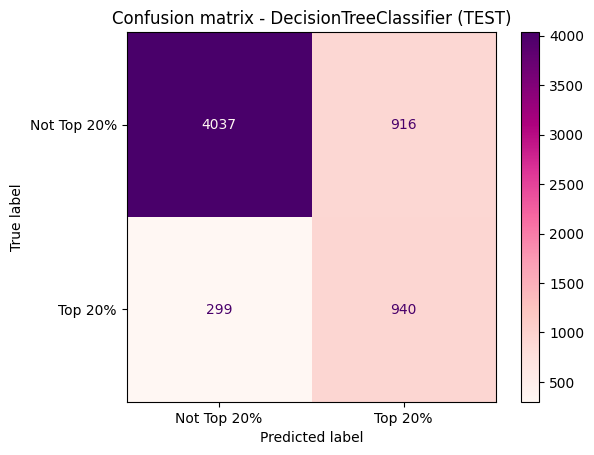


Detaljer per klass (classification_report)
              precision    recall  f1-score   support

 Not Top 20%       0.93      0.82      0.87      4953
     Top 20%       0.51      0.76      0.61      1239

    accuracy                           0.80      6192
   macro avg       0.72      0.79      0.74      6192
weighted avg       0.85      0.80      0.82      6192

TN=4037, FP=916, FN=299, TP=940
Tolkning
- FP: vi flaggade positivt med det var negativt
- FN: vi missade positivt och flaggade det som negativt


In [29]:
# Final evaluation of the selected model on the test set using the same evaluation function as before to get a comprehensive report of the model's performance on unseen data.

test_results = data_prep.evaluate_on_test(winner, X_test_ready
                                , y_test, target_names)


In [30]:
# Creating a summary table to compare the baseline CV performance, the tuned CV performance, and the final test performance of the selected model. 
# This will help us visualize the improvements from tuning and how well the model generalizes to unseen data.

baseline_df = baseline_table.copy()
baseline_df["type"] = "CV (baseline)"
baseline_df.rename(columns={"mean": "recall"}, inplace=True)
baseline_df = baseline_df[["model", "recall", "type"]]

tuned_df = pd.DataFrame([
    {"model": "RandomForest", "recall": round(grid_rf_best.best_score_, 3), "type": "CV (tuned)"},
    {"model": "DecisionTree", "recall": round(grid_tree_best.best_score_, 3), "type": "CV (tuned)"}
])

test_df = pd.DataFrame([
    {
        "model": "DecisionTree",
        "recall": test_results["recall"],
        "type": "TEST"
    }
])

results_df = pd.concat([baseline_df, tuned_df, test_df], ignore_index=True)

results_df

,model,recall,type
0,DecisionTree,0.584921,CV (baseline)
1,RandomForest,0.576964,CV (baseline)
2,LogisticRegression,0.535113,CV (baseline)
3,RandomForest,0.589000,CV (tuned)
4,DecisionTree,0.754000,CV (tuned)
5,DecisionTree,0.758676,TEST


Saved figure to Model_Comparison_and_Confusion_Matrix.png


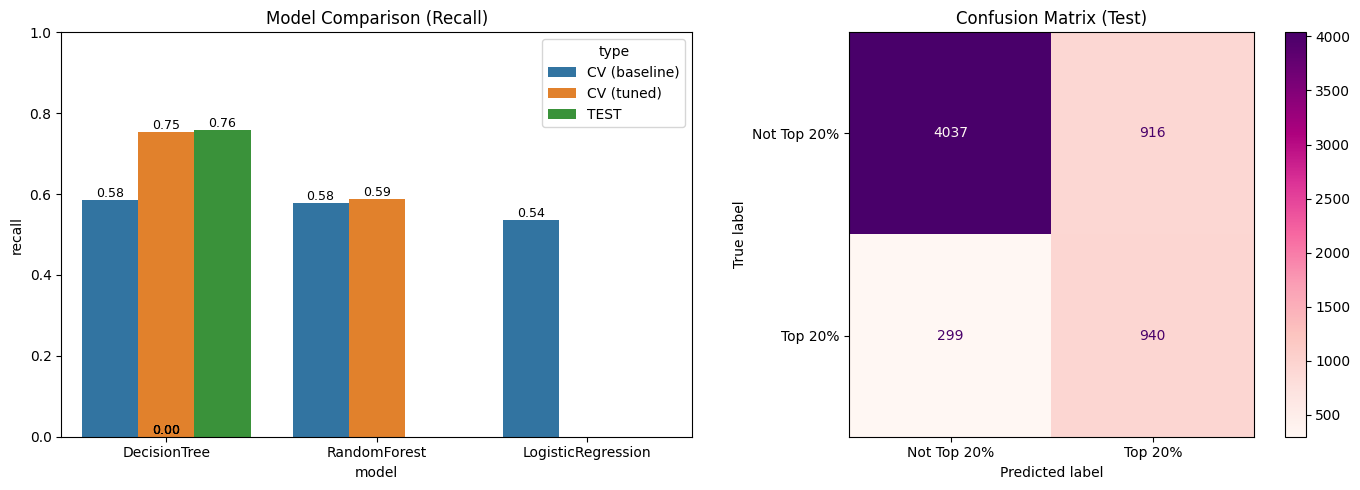

In [31]:
# Visualizing the comparison of model performance across the different stages (baseline CV, tuned CV, and test) using a bar plot for recall scores and a confusion matrix for the test set to show the distribution of true positives, false positives, true negatives, and false negatives.

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Left: barplot
sns.barplot(data=results_df, x="model", y="recall", hue="type", ax=axes[0])
axes[0].set_title("Model Comparison (Recall)")
axes[0].set_ylim(0,1)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}",
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=9)

# Right: confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=test_results["cm"], display_labels=target_names)
disp.plot(ax=axes[1], cmap="RdPu")
axes[1].set_title("Confusion Matrix (Test)")

plt.tight_layout()
save_plot(fig, "Model_Comparison_and_Confusion_Matrix.png")
plt.show()

In [32]:
# Dataframe as a base for error analysis report
# Predictions
y_pred = winner.predict(X_test_ready)

# Create analysis dataframe
analysis_df = pd.DataFrame(X_test_ready.copy())
analysis_df["y_true"] = y_test.values
analysis_df["y_pred"] = y_pred

# Define groups
analysis_df["error_type"] = "correct"
analysis_df.loc[(analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 0), "error_type"] = "FN"
analysis_df.loc[(analysis_df["y_true"] == 0) & (analysis_df["y_pred"] == 1), "error_type"] = "FP"

X_test_pca = pca.transform(X_test_ready)


pca_cols = [f"PC{i+1}" for i in range(X_test_pca.shape[1])]
pca_df = pd.DataFrame(X_test_pca, columns=pca_cols)


analysis_df = pd.concat([pca_df, analysis_df[["y_true", "y_pred", "error_type"]].reset_index(drop=True)], axis=1)

In [33]:
# Grouped view of error types and their mean values across the PCA components to understand if certain types of errors are associated with specific patterns in the PCA-transformed feature space. 
# This can help identify if the model is struggling with certain regions of the feature space that correspond to specific error types (e.g., false negatives or false positives).
# Mean values per group
group_means = analysis_df.groupby("error_type").mean()

display(group_means)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,y_true,y_pred
error_type,,,,,,,,,,,
FN,-0.170187,-0.001081,0.130959,0.255189,0.092974,0.036304,-0.008479,0.003409,-1.856560e-17,1.000000,0.000000
FP,0.112316,0.268692,0.386981,0.100200,0.091587,0.026834,-0.018579,-0.000319,2.727076e-18,0.000000,1.000000
correct,-0.009976,-0.050249,-0.080941,-0.040172,-0.023646,-0.010434,0.002405,-0.000260,-4.787098e-17,0.188869,0.188869


Saved figure to PCA_error_analysis.png


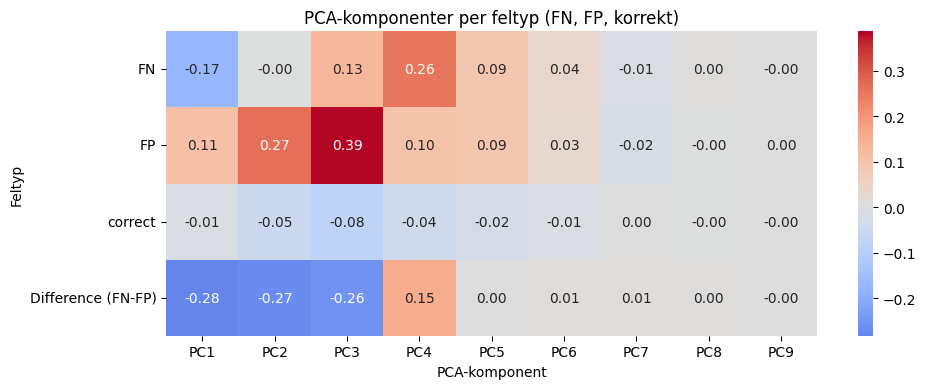

In [34]:
# Visualize the mean PCA component values for each error type using a heatmap to identify if there are specific patterns in the PCA space that correspond to false negatives, false positives, or correct predictions.

group_means.loc["Difference (FN-FP)"] = group_means.loc["FN"] - group_means.loc["FP"]

analysis_plot = group_means.filter(like="PC")

fig = plt.figure(figsize=(10, 4))

sns.heatmap(
    analysis_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("PCA-komponenter per feltyp (FN, FP, korrekt)")
plt.ylabel("Feltyp")
plt.xlabel("PCA-komponent")
plt.tight_layout()

save_plot(fig, "PCA_error_analysis.png")
plt.show()

### Slutlig test-prestanda
Vid utvärdering på testdata uppnådde modellen följande resultat:

- **Accuracy:** 0.804  
- **Precision:** 0.506  
- **Recall:** 0.759  
- **F1-score:** 0.607  

Modellen identifierar majoriteten av högprisområden (hög recall), men med en relativt hög andel falska positiva (lägre precision), vilket är ett medvetet val baserat på affärsmålet.

---

### Fördjupad felanalys (PCA-baserad)

**False Negatives (FN):**
- Lägre värden i **PC1** (boendestandard per hushåll)  
- Högre värden i **PC4** (geografiskt läge, t.ex. ocean proximity)  

Modellen missar vissa högprisområden där **geografi väger tyngre än boendestandard**.

---

**False Positives (FP):**
- Höga värden i **PC2** (inkomst och ålder)  
- Höga värden i **PC3** (bostäders ålder)  

Modellen överskattar områden med **starka socioekonomiska signaler**, även när de inte tillhör topp 20%.

---

**Korrekta prediktioner:**
Ligger nära noll i de flesta komponenter  
Modellen fungerar bäst på “typiska” observationer utan extrema värden.

---

### Sammanfattning

Våra resultat visar att Decision Tree-modellen är stabil med en CV-Recall på 0,754 och ett test-recall på 0,759, vilket tyder på att modellen generaliserar väl till ny, osedd data. Variation mellan olika modeller och parametrar var relativt liten, vilket indikerar en viss robusthet, men vissa osäkerheter kvarstår kring ovanliga eller extrema observationer.

Modellen gör främst fel vid områden där boendestandard (PC1) och geografiskt läge (PC4) ger motstridiga signaler. **False Negatives (FN)** innebär att högprisområden inte identifieras, vilket kan leda till att resurser inte prioriteras där de behövs. **False Positives (FP)** innebär att områden flaggas som högpris trots att de inte är det, vilket kan ge onödiga insatser men är mindre kritiskt än att missa ett högprisområde.
Trots detta är modellen väl anpassad till uppdraget, där det är viktigare att fånga så många högprisområden som möjligt än att minimera falska positiva.